In [74]:
import pandas as pd
from pathlib import Path
import re

RAW_DIR = Path("raw")
CLEAN_DIR = Path("cleaned")

CLEAN_DIR.mkdir(exist_ok=True)

def read_weather_csv(path):
    """Read CSV with encoding fallback"""
    encodings = ["utf-8", "cp1252", "latin1"]

    for enc in encodings:
        try:
            df = pd.read_csv(
                path,
                skiprows=5,
                encoding=enc,
                engine="python"
            )
            return df
        except UnicodeDecodeError:
            continue

    raise RuntimeError(f"Could not read file: {path}")


def normalize_column(name):
    """
    Normalize column names
    Example:
    'Temperature (°C)' -> temperature_c
    'Wind Speed (km/h)' -> wind_speed_km_h
    """

    name = str(name)

    name = name.replace("°", "deg")
    name = name.replace("%", "pct")

    name = name.lower()

    name = re.sub(r"[()]", "", name)
    name = re.sub(r"[^a-z0-9]+", "_", name)

    name = re.sub(r"_+", "_", name)

    return name.strip("_")


def clean_dataset(file_path):

    print(f"Processing {file_path.name}")

    df = read_weather_csv(file_path)

    # Normalize column names
    df.columns = [normalize_column(c) for c in df.columns]

    # Drop empty rows
    df = df.dropna(how="all")

    df = df.reset_index(drop=True)

    return df


cleaned_frames = []

for csv_file in sorted(RAW_DIR.glob("*.csv")):

    df = clean_dataset(csv_file)

    cleaned_frames.append(df)

    output_path = CLEAN_DIR / f"{csv_file.stem}_cleaned.csv"

    df.to_csv(output_path, index=False, encoding="utf-8")

    print(f"Saved cleaned file -> {output_path}\n")


print("Merging yearly datasets...")

merged = pd.concat(cleaned_frames, ignore_index=True)


# Try to detect datetime column automatically
datetime_candidates = [c for c in merged.columns if "time" in c or "date" in c]

if datetime_candidates:
    dt_col = datetime_candidates[0]

    merged[dt_col] = pd.to_datetime(merged[dt_col], errors="coerce")

    merged = merged.sort_values(dt_col)

    merged = merged.drop_duplicates(subset=[dt_col])


merged = merged.reset_index(drop=True)


merged_path = CLEAN_DIR / "kiit_weather_merged.csv"

merged.to_csv(
    merged_path,
    index=False,
    encoding="utf-8"
)

print(f"Merged dataset saved -> {merged_path}")

print(f"Final merged shape: {merged.shape}")

Processing KIIT_University_Weather_1-1-24_12-00_AM_1_Year_1769149830_v2.csv
Saved cleaned file -> cleaned/KIIT_University_Weather_1-1-24_12-00_AM_1_Year_1769149830_v2_cleaned.csv

Processing KIIT_University_Weather_1-1-25_12-00_AM_1_Year_1769149928_v2.csv
Saved cleaned file -> cleaned/KIIT_University_Weather_1-1-25_12-00_AM_1_Year_1769149928_v2_cleaned.csv

Processing KIIT_University_Weather_1-1-26_12-00_AM_1_Year_1769149953_v2.csv
Saved cleaned file -> cleaned/KIIT_University_Weather_1-1-26_12-00_AM_1_Year_1769149953_v2_cleaned.csv

Merging yearly datasets...


/tmp/ipykernel_13245/195712673.py:95: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged[dt_col] = pd.to_datetime(merged[dt_col], errors="coerce")


Merged dataset saved -> cleaned/kiit_weather_merged.csv
Final merged shape: (109608, 72)


/tmp/ipykernel_13245/2301649632.py:7: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./cleaned/kiit_weather_merged.csv")


Dataset Shape: (109608, 72)

Total Missing Values: 1623499

Missing Value Summary:


,missing_count,missing_percent
et_mm,94261,85.998285
high_aqi,48331,44.094409
high_temp_degc_1,48329,44.092584
temp_degc_1,48329,44.092584
high_pm_10_ug_m,48329,44.092584
...,...,...
high_inside_hum_pct,1846,1.684184
inside_heat_index_degc,1846,1.684184
high_bar_mb,1846,1.684184
barometer_mb,1846,1.684184



Missing Pattern:


,missing_pattern
inside_temp_degc,Missing at Beginning & End
high_inside_temp_degc,Missing at Beginning & End
low_inside_temp_degc,Missing at Beginning & End
inside_hum_pct,Missing at Beginning & End
high_inside_hum_pct,Missing at Beginning & End
...,...
wet_bulb_degc_1,Missing at Beginning & End
high_wet_bulb_degc_1,Missing at Beginning & End
low_wet_bulb_degc_1,Missing at Beginning & End
heat_index_degc_1,Missing at Beginning & End


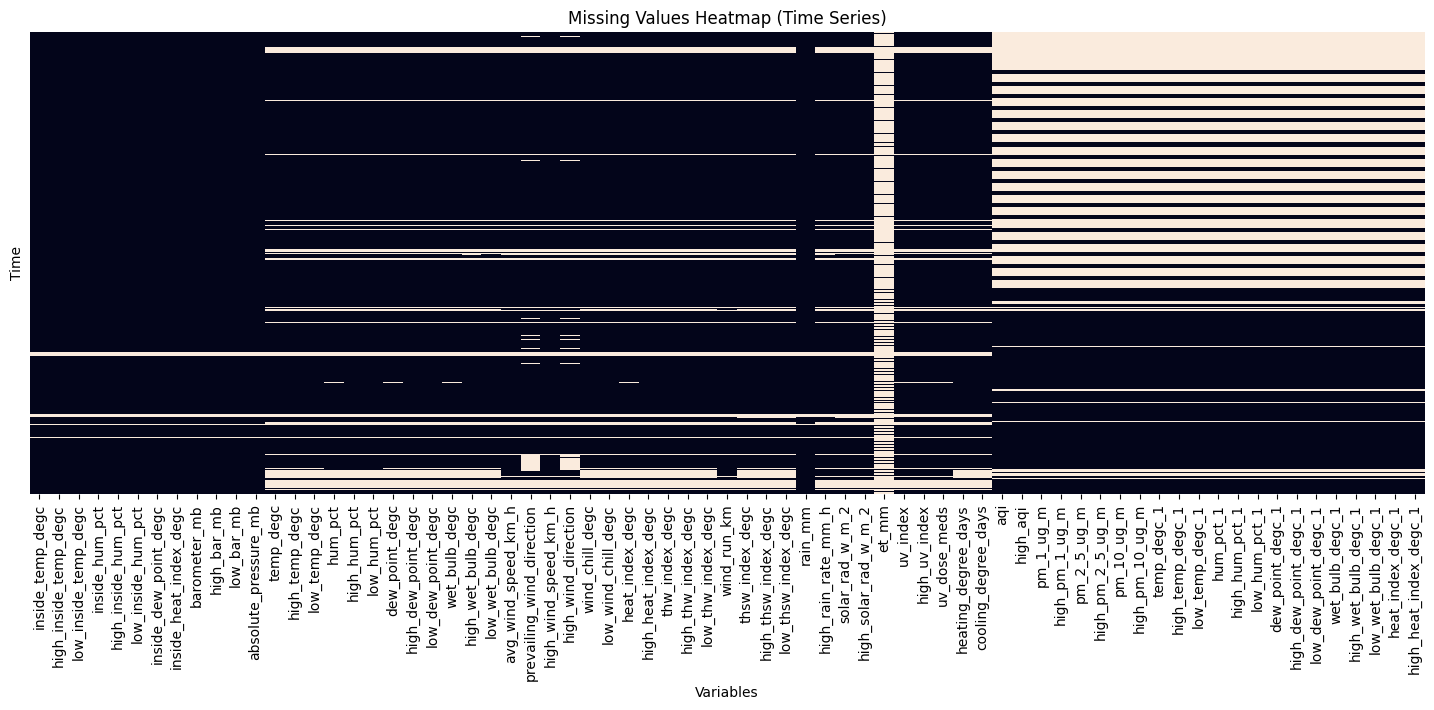

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("./cleaned/kiit_weather_merged.csv")

# Convert '--' to NaN
df.replace("--", np.nan, inplace=True)

# Parse datetime
df["date_time"] = pd.to_datetime(df["date_time"])

# Sort by time
df = df.sort_values("date_time").reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("\nTotal Missing Values:", df.isna().sum().sum())

# Missing values per column
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
}).sort_values("missing_percent", ascending=False)

print("\nMissing Value Summary:")
display(missing_summary[missing_summary["missing_count"] > 0])

# Detect position of missing values (start, end, random)
def missing_position(series):
    if series.isna().all():
        return "All Missing"
    
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()
    
    if first_valid is None:
        return "All Missing"
    
    start_missing = series.iloc[:first_valid].isna().all()
    end_missing = series.iloc[last_valid+1:].isna().all()
    
    if start_missing and not end_missing:
        return "Missing at Beginning"
    elif end_missing and not start_missing:
        return "Missing at End"
    elif start_missing and end_missing:
        return "Missing at Beginning & End"
    elif series.isna().any():
        return "Random Missing"
    else:
        return "No Missing"

missing_pattern = {col: missing_position(df[col]) for col in df.columns if col != "date_time"}

pattern_df = pd.DataFrame.from_dict(missing_pattern, orient="index", columns=["missing_pattern"])
print("\nMissing Pattern:")
display(pattern_df)

# Heatmap of missing values over time
plt.figure(figsize=(18,6))
sns.heatmap(df.set_index("date_time").isna(),
            cbar=False,
            yticklabels=False)

plt.title("Missing Values Heatmap (Time Series)")
plt.xlabel("Variables")
plt.ylabel("Time")
plt.show()

In [76]:
print("Total rows:", len(df))

print("Start timestamp:", df["date_time"].min())
print("End timestamp:", df["date_time"].max())

print("Unique timestamps:", df["date_time"].nunique())

Total rows: 109608
Start timestamp: 2024-01-23 12:30:00
End timestamp: 2026-01-23 12:00:00
Unique timestamps: 109608


In [77]:
duplicates = df[df["date_time"].duplicated()]

print("Duplicate timestamps:", len(duplicates))

display(duplicates.head())

Duplicate timestamps: 0


,date_time,inside_temp_degc,high_inside_temp_degc,low_inside_temp_degc,inside_hum_pct,high_inside_hum_pct,low_inside_hum_pct,inside_dew_point_degc,inside_heat_index_degc,barometer_mb,...,high_hum_pct_1,low_hum_pct_1,dew_point_degc_1,high_dew_point_degc_1,low_dew_point_degc_1,wet_bulb_degc_1,high_wet_bulb_degc_1,low_wet_bulb_degc_1,heat_index_degc_1,high_heat_index_degc_1


In [78]:
time_diffs = df["date_time"].diff()

display(time_diffs.value_counts().head(10))

date_time
0 days 00:05:00    60607
0 days 00:15:00    48992
0 days 00:30:00        2
0 days 12:15:00        1
0 days 00:10:00        1
0 days 14:15:00        1
8 days 19:45:00        1
0 days 03:30:00        1
0 days 02:00:00        1
Name: count, dtype: int64

In [51]:
import pandas as pd
import numpy as np

df = pd.read_csv("./cleaned/kiit_weather_merged.csv")

df.replace("--", np.nan, inplace=True)
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

segments = []

for col in df.columns:
    
    if col == "date_time":
        continue

    series = pd.to_numeric(df[col], errors="coerce")
    valid_idx = series.dropna().index

    if len(valid_idx) < 20:
        continue

    gaps = np.diff(valid_idx)

    start_i = 0

    for i in range(1, len(gaps)):
        
        if gaps[i] != gaps[i-1]:

            segments.append({
                "column": col,
                "start_row": valid_idx[start_i],
                "end_row": valid_idx[i],
                "start_time": df.loc[valid_idx[start_i],"date_time"],
                "end_time": df.loc[valid_idx[i],"date_time"],
                "periodicity": gaps[i-1],
                "segment_length": i-start_i
            })

            start_i = i

    segments.append({
        "column": col,
        "start_row": valid_idx[start_i],
        "end_row": valid_idx[-1],
        "start_time": df.loc[valid_idx[start_i],"date_time"],
        "end_time": df.loc[valid_idx[-1],"date_time"],
        "periodicity": gaps[-1],
        "segment_length": len(valid_idx)-start_i
    })

segments_df = pd.DataFrame(segments)

segments_df = segments_df.sort_values(["column","start_time"])

segments_df.to_csv("sensor_periodicity_segments.csv", index=False)

display(segments_df)

/tmp/ipykernel_13245/698127930.py:4: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./cleaned/kiit_weather_merged.csv")


,column,start_row,end_row,start_time,end_time,periodicity,segment_length
143,absolute_pressure_mb,0,76065,2024-01-23 12:30:00,2025-02-07 21:00:00,1,76065
144,absolute_pressure_mb,76065,76827,2025-02-07 21:00:00,2025-02-15 19:30:00,762,1
145,absolute_pressure_mb,76827,88708,2025-02-15 19:30:00,2025-06-19 14:00:00,1,11881
146,absolute_pressure_mb,88708,88710,2025-06-19 14:00:00,2025-06-19 14:30:00,2,1
147,absolute_pressure_mb,88710,90548,2025-06-19 14:30:00,2025-07-08 18:00:00,1,1838
...,...,...,...,...,...,...,...
30536,wind_run_km,109418,109425,2026-01-21 12:45:00,2026-01-21 14:30:00,1,7
30537,wind_run_km,109425,109427,2026-01-21 14:30:00,2026-01-21 15:00:00,2,1
30538,wind_run_km,109427,109434,2026-01-21 15:00:00,2026-01-21 16:45:00,1,7
30539,wind_run_km,109434,109438,2026-01-21 16:45:00,2026-01-21 17:45:00,4,1


/tmp/ipykernel_13245/2298184341.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean())


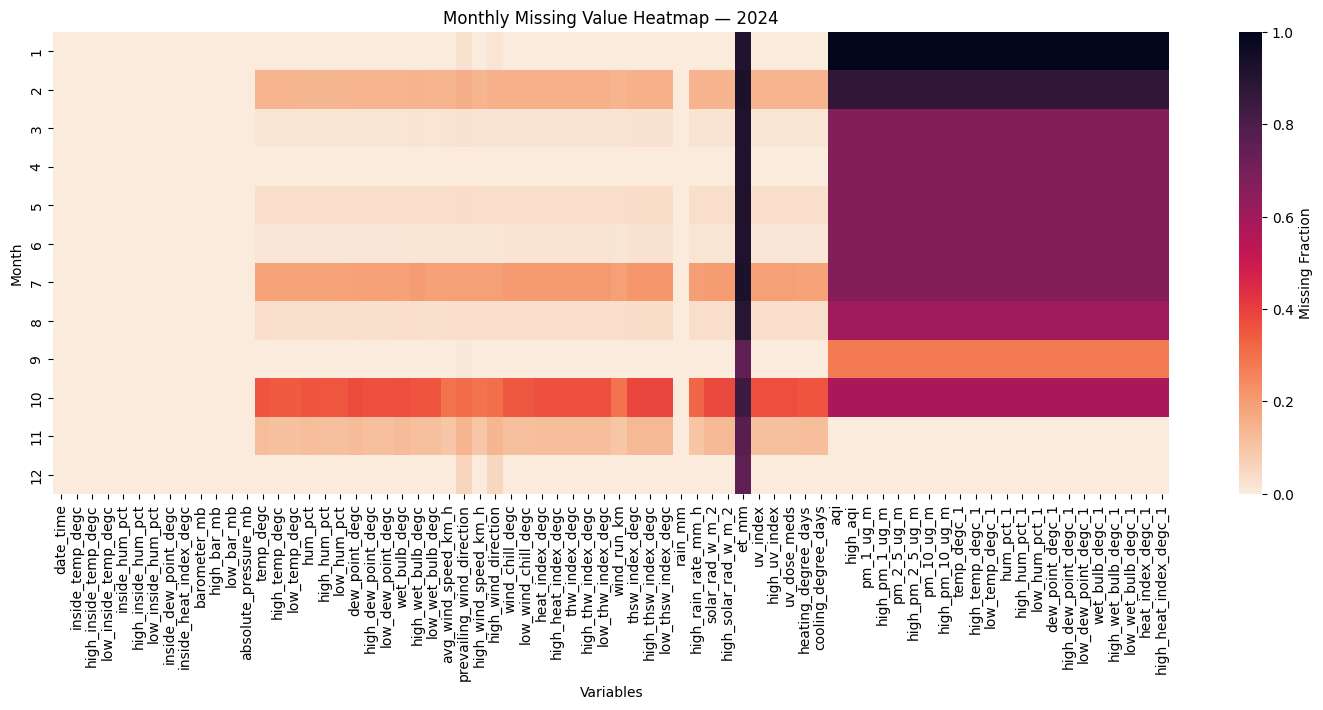

/tmp/ipykernel_13245/2298184341.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean())


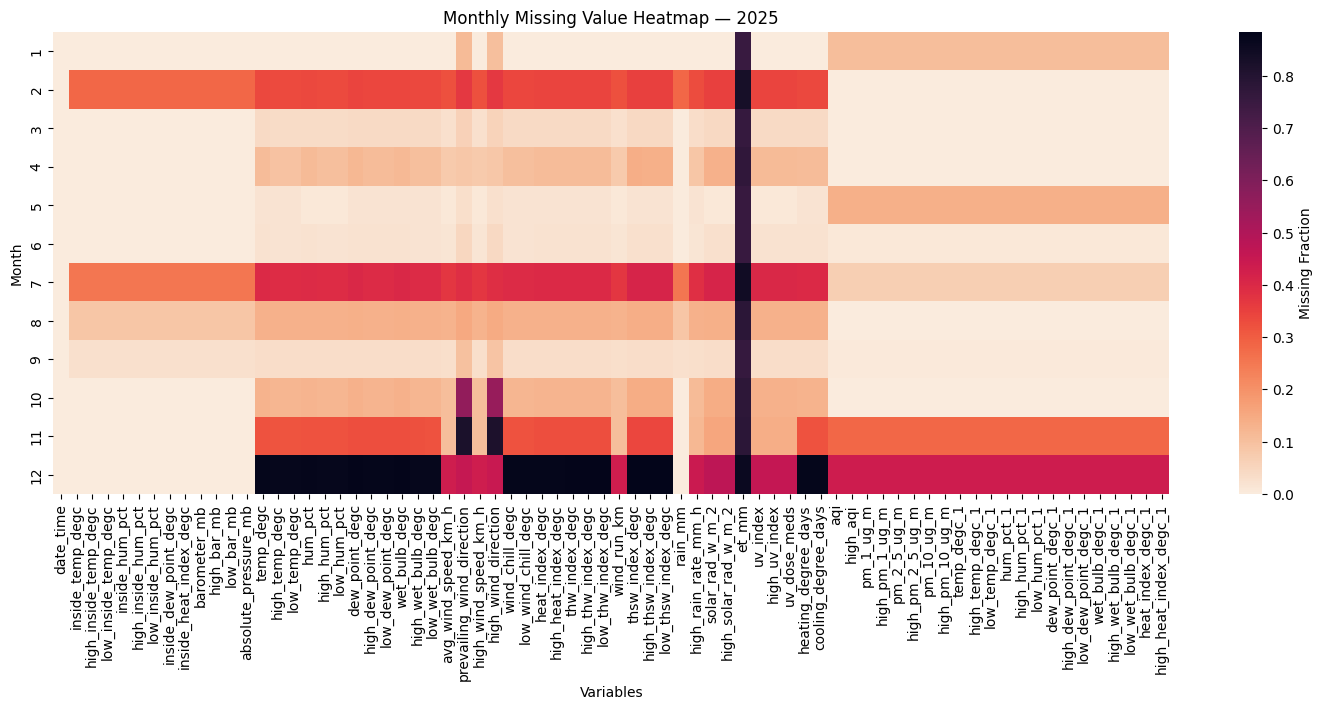

/tmp/ipykernel_13245/2298184341.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean())


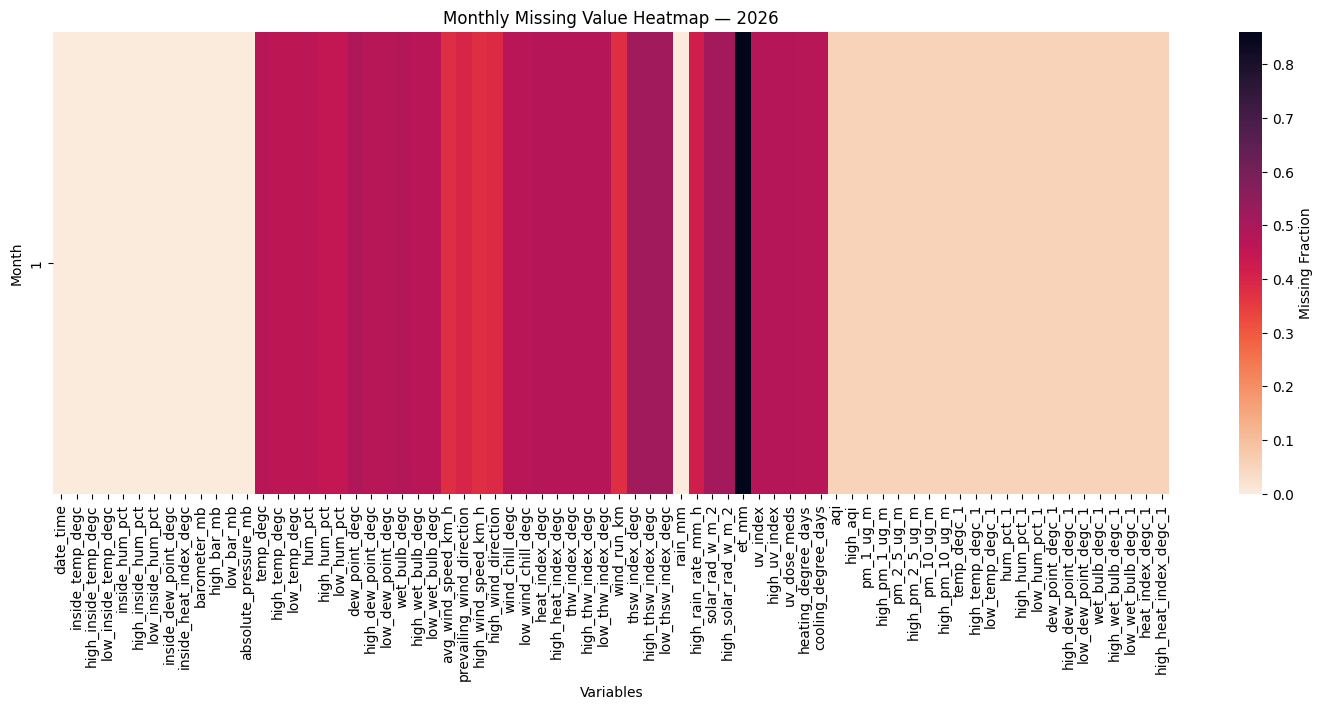

In [53]:
# Add year and month columns
df["year"] = df["date_time"].dt.year
df["month"] = df["date_time"].dt.month

years = sorted(df["year"].unique())

for year in years:
    
    df_year = df[df["year"] == year]
    
    # Compute monthly missing fraction
    monthly_missing = (
        df_year
        .groupby("month")
        .apply(lambda x: x.isna().mean())
    )
    
    # Remove helper columns
    monthly_missing = monthly_missing.drop(columns=["year","month"], errors="ignore")
    
    plt.figure(figsize=(18,6))
    
    sns.heatmap(
        monthly_missing,
        cmap="rocket_r",
        cbar_kws={"label": "Missing Fraction"}
    )
    
    plt.title(f"Monthly Missing Value Heatmap — {year}")
    plt.xlabel("Variables")
    plt.ylabel("Month")
    
    plt.show()

/tmp/ipykernel_13245/743096053.py:10: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./cleaned/kiit_weather_merged.csv")


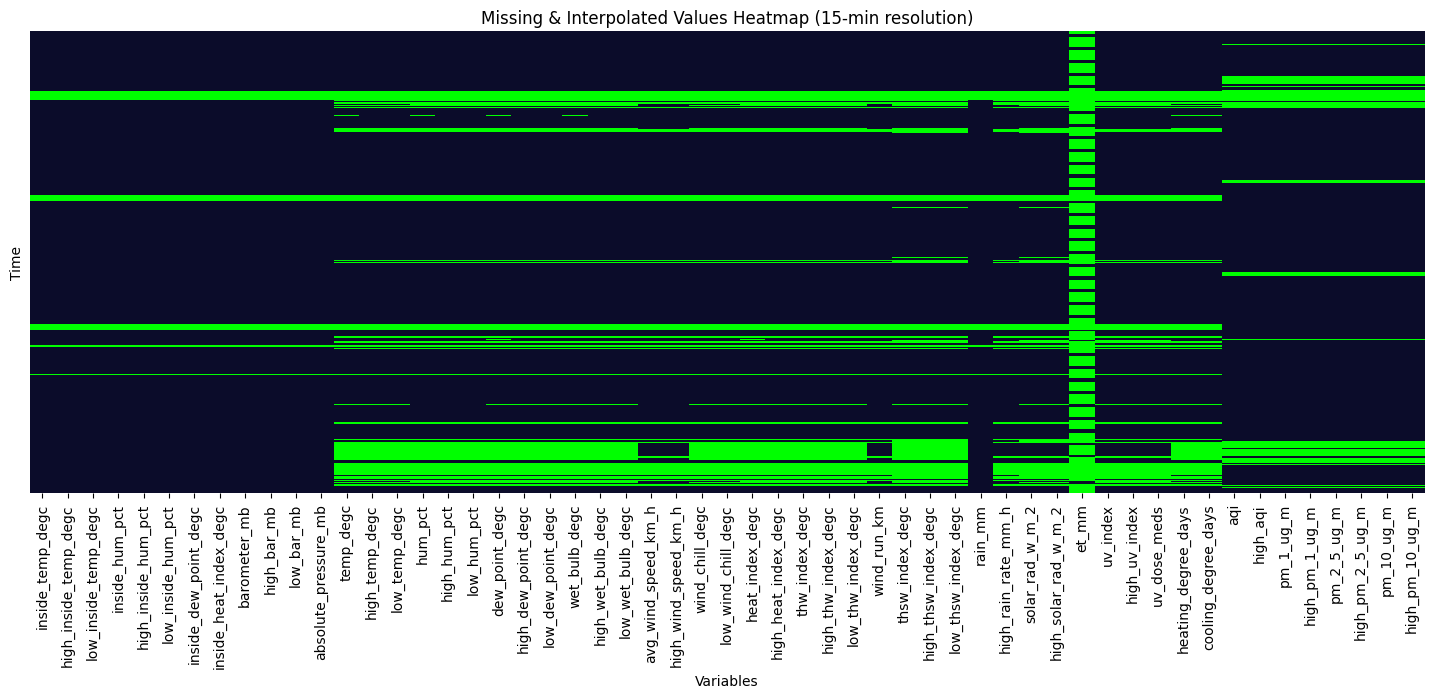

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# ----------------------------
# Load dataset
# ----------------------------
df = pd.read_csv("./cleaned/kiit_weather_merged.csv")

df.replace("--", np.nan, inplace=True)

df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

# ----------------------------
# Trim dataset
# ----------------------------
df = df[df["date_time"] >= "2024-08-01"].reset_index(drop=True)

# ----------------------------
# Drop useless features
# ----------------------------
drop_cols = [
    "prevailing_wind_direction",
    "high_wind_direction",

    "temp_degc_1","high_temp_degc_1","low_temp_degc_1",
    "hum_pct_1","high_hum_pct_1","low_hum_pct_1",
    "dew_point_degc_1","high_dew_point_degc_1","low_dew_point_degc_1",
    "wet_bulb_degc_1","high_wet_bulb_degc_1","low_wet_bulb_degc_1",
    "heat_index_degc_1","high_heat_index_degc_1"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# ----------------------------
# Convert numeric columns
# ----------------------------
for col in df.columns:
    if col != "date_time":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ----------------------------
# Set index
# ----------------------------
df = df.set_index("date_time")

# ----------------------------
# Resample to 15-minute resolution
# ----------------------------
df = df.resample("15min").mean()

# ----------------------------
# Save original missing mask
# ----------------------------
original_missing = df.isna()

# ----------------------------
# Interpolate
# ----------------------------
df_interp = df.interpolate(method="time")
df_interp = df_interp.ffill().bfill()

# ----------------------------
# Detect interpolated values
# ----------------------------
interpolated_mask = original_missing & df_interp.notna()

# ----------------------------
# Visualization matrix
# ----------------------------
viz_matrix = np.zeros(df_interp.shape)

viz_matrix[df_interp.isna()] = 1
viz_matrix[interpolated_mask.values] = 2

# ----------------------------
# Color map
# ----------------------------
cmap = ListedColormap([
    "#0b0c2a",   # original
    "#ffffff",   # missing
    "#00ff00"    # interpolated
])

# ----------------------------
# Heatmap
# ----------------------------
plt.figure(figsize=(18,6))

sns.heatmap(
    viz_matrix,
    cmap=cmap,
    cbar=False,
    yticklabels=False,
    xticklabels=df_interp.columns
)

plt.title("Missing & Interpolated Values Heatmap (15-min resolution)")
plt.xlabel("Variables")
plt.ylabel("Time")

plt.show()

In [106]:
# Reset index so date_time becomes a column again
df_clean = df_interp.reset_index()

# Save cleaned dataset
df_clean.to_csv("./cleaned/kiit_weather_cleaned.csv", index=False)

print("Cleaned dataset saved to ./cleaned/kiit_weather_cleaned.csv")
print("Final shape:", df_clean.shape)

Cleaned dataset saved to ./cleaned/kiit_weather_cleaned.csv
Final shape: (51889, 56)


### Data Cleaning and Preparation Overview

The original dataset consisted of multivariate weather station observations recorded at regular time intervals. However, exploratory analysis revealed significant missingness across several variables, especially those related to air quality measurements. Since the objective of the study is focused on **AQI and temperature prediction**, the preprocessing pipeline was designed to retain meaningful signals while removing structural noise and sensor artifacts.

The first step involved **visualizing missing values over time** using a full time-series heatmap. This allowed us to distinguish between two types of missing data: **structural missingness** caused by sensors not yet being operational, and **periodic missingness** caused by sensors operating at lower sampling frequencies than the main station logger. The heatmap and month-wise missingness analysis clearly showed that **AQI and particulate matter sensors were largely inactive before August 2024**. Prior to this period, the AQI column contained extremely sparse data and therefore did not provide reliable information for predictive modelling. Including this section of the dataset would introduce artificial noise and bias models toward missing patterns rather than meaningful atmospheric relationships. For this reason, the dataset was **trimmed so that the new starting point is August 2024**, the point at which AQI readings became consistently available.

After trimming, another issue became evident: several variables had large numbers of missing values because different sensors operate at **different sampling periodicities**. For example, some sensors record measurements at every timestamp, while others record readings every **third timestamp**. This pattern does not indicate actual absence of information but rather a **lower-frequency sampling schedule**. To address this, the dataset was interpolated using **time-based interpolation**, which estimates missing values based on surrounding timestamps. Time interpolation is particularly suitable for environmental time-series because meteorological variables such as temperature, humidity, pressure, and AQI typically change smoothly over short time intervals. This method reconstructs intermediate values in a physically reasonable manner without introducing abrupt discontinuities. After interpolation, forward and backward filling were applied to handle any remaining edge gaps.

During preprocessing it was also observed that some columns were either **categorical or redundant sensor duplicates** that contributed large amounts of missing values without improving predictive capability. In particular, wind direction variables are categorical and cannot be meaningfully interpolated, while the secondary sensor block (`*_1` variables) represents auxiliary measurements that are sparsely populated. These columns were removed from the dataset to improve data quality and reduce noise in downstream models.

Finally, the cleaned dataset was visualized again using a heatmap where **interpolated values were highlighted**, allowing verification that interpolation primarily filled periodic sampling gaps rather than long outages. The resulting dataset contains continuous time-series observations with minimal missing values and consistent temporal resolution, making it suitable for machine learning models aimed at **air quality and temperature forecasting**.

---

### Remaining Features and Their Relevance

After cleaning, the remaining variables consist primarily of meteorological and air-quality related measurements. Their importance for predicting **AQI** and **temperature** can be ranked based on known atmospheric relationships and empirical evidence from environmental modelling.

---

# Feature Importance for AQI Prediction

**Tier 1 – Direct AQI Drivers (Highest Importance)**

1. `pm_2_5_ug_m` – primary pollutant used in AQI calculation
2. `pm_10_ug_m` – coarse particulate concentration
3. `pm_1_ug_m` – fine particulate concentration
4. `temp_degc` – temperature strongly influences pollutant chemistry
5. `hum_pct` – humidity affects particulate formation and dispersion

**Tier 2 – Atmospheric Conditions Influencing Dispersion**
6. `avg_wind_speed_km_h` – pollutant dispersion
7. `high_wind_speed_km_h`
8. `barometer_mb` – atmospheric pressure systems influence air stagnation
9. `absolute_pressure_mb`
10. `dew_point_degc` – moisture–pollution interaction

**Tier 3 – Secondary Environmental Factors**
11. `solar_rad_w_m_2` – photochemical reactions affecting pollution
12. `uv_index` – photochemical smog formation
13. `rain_mm` – precipitation removes particulates
14. `wet_bulb_degc`

**Tier 4 – Derived Thermal Indices (Lower Importance)**
15. `heat_index_degc`
16. `thw_index_degc`
17. `thsw_index_degc`
18. `wind_chill_degc`

---

# Feature Importance for Temperature Prediction

**Tier 1 – Core Temperature Indicators**

1. `temp_degc`
2. `high_temp_degc`
3. `low_temp_degc`
4. `inside_temp_degc`

**Tier 2 – Moisture and Thermal Balance Variables**
5. `dew_point_degc`
6. `hum_pct`
7. `wet_bulb_degc`

**Tier 3 – Radiation and Energy Balance**
8. `solar_rad_w_m_2`
9. `uv_index`

**Tier 4 – Atmospheric and Wind Influences**
10. `avg_wind_speed_km_h`
11. `barometer_mb`
12. `absolute_pressure_mb`

**Tier 5 – Derived Thermal Indices**
13. `heat_index_degc`
14. `thw_index_degc`
15. `thsw_index_degc`

---

The preprocessing pipeline focused on **removing structural missingness, preserving meaningful temporal relationships, and reconstructing periodic sensor gaps** through time interpolation. Trimming the dataset to August 2024 ensures that AQI measurements are consistently available, while dropping redundant or categorical variables improves dataset quality. The resulting cleaned dataset contains continuous meteorological and air-quality measurements suitable for predictive modelling. Among the remaining variables, particulate concentrations and meteorological dispersion factors are the strongest predictors for AQI, while temperature prediction relies primarily on direct thermal measurements, humidity variables, and solar radiation indicators.


During the preprocessing stage, the temporal integrity of the dataset was verified by analyzing the differences between consecutive timestamps. This was done by computing the time difference between each pair of adjacent observations and examining the frequency distribution of these intervals. The analysis revealed that the majority of timestamps were separated by **15-minute intervals**, confirming that the primary sampling resolution of the dataset is 15 minutes. However, a significant number of **5-minute differences** were also observed. These shorter intervals do not necessarily indicate that the dataset was originally sampled every 5 minutes; rather, they are likely the result of irregular logging patterns, slight timestamp offsets, or missing intermediate records during data collection or merging from multiple sensors. A few rare larger gaps (such as 30 minutes or several hours) were also detected, which likely correspond to brief sensor outages or station downtime.

To ensure a consistent temporal structure for time-series modeling, the dataset was subsequently **resampled to a strict 15-minute time grid**. Resampling aligns all observations to a uniform temporal framework, eliminating irregular timestamp offsets and ensuring that each observation corresponds to a fixed interval in time. Interestingly, the size of the dataset remained largely unchanged after resampling, which indicates that the original data was already predominantly aligned with the 15-minute grid despite the occasional irregular intervals observed in the timestamp difference analysis. Establishing a consistent temporal resolution is essential for downstream forecasting models because it guarantees that lag features, rolling statistics, and other temporal transformations operate on a stable and predictable time axis.


## EDA

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./cleaned/kiit_weather_cleaned.csv")

df["date_time"] = pd.to_datetime(df["date_time"])

df = df.sort_values("date_time")

df.set_index("date_time", inplace=True)

print("Dataset shape:", df.shape)

display(df.head())
display(df.describe())

Dataset shape: (51889, 55)


,inside_temp_degc,high_inside_temp_degc,low_inside_temp_degc,inside_hum_pct,high_inside_hum_pct,low_inside_hum_pct,inside_dew_point_degc,inside_heat_index_degc,barometer_mb,high_bar_mb,...,heating_degree_days,cooling_degree_days,aqi,high_aqi,pm_1_ug_m,high_pm_1_ug_m,pm_2_5_ug_m,high_pm_2_5_ug_m,pm_10_ug_m,high_pm_10_ug_m
date_time,,,,,,,,,,,,,,,,,,,,,
2024-08-01 00:00:00,24.900000,24.933333,24.766667,64.800000,65.566667,64.033333,17.8,25.566667,1004.200000,1004.266667,...,0.0,0.032000,110.5,121.9,25.5,29.0,39.4,44.0,50.2,58.0
2024-08-01 00:15:00,25.066667,25.166667,25.066667,63.866667,64.000000,63.866667,17.8,25.766667,1004.133333,1004.200000,...,0.0,0.032000,107.7,119.5,24.8,28.0,38.2,43.0,48.3,58.0
2024-08-01 00:30:00,25.266667,25.366667,25.233333,63.400000,63.600000,63.400000,17.8,26.000000,1004.033333,1004.133333,...,0.0,0.031667,102.0,119.5,23.5,27.0,35.9,43.0,45.3,55.0
2024-08-01 00:45:00,25.500000,25.500000,25.366667,63.200000,63.266667,63.066667,18.0,26.233333,1003.900000,1003.966667,...,0.0,0.031667,92.2,109.6,20.4,26.0,31.2,39.0,37.0,51.0
2024-08-01 01:00:00,25.566667,25.633333,25.500000,63.333333,63.366667,63.200000,18.1,26.300000,1003.766667,1003.800000,...,0.0,0.031000,77.0,93.7,15.7,21.0,23.1,32.0,26.2,41.0


,inside_temp_degc,high_inside_temp_degc,low_inside_temp_degc,inside_hum_pct,high_inside_hum_pct,low_inside_hum_pct,inside_dew_point_degc,inside_heat_index_degc,barometer_mb,high_bar_mb,...,heating_degree_days,cooling_degree_days,aqi,high_aqi,pm_1_ug_m,high_pm_1_ug_m,pm_2_5_ug_m,high_pm_2_5_ug_m,pm_10_ug_m,high_pm_10_ug_m
count,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,...,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000,51889.000000
mean,26.481663,26.607957,26.345948,63.769223,64.401459,63.150573,18.982979,27.888806,1011.516170,1011.620758,...,0.000733,0.083898,128.087371,141.625503,34.893158,40.496907,59.027782,69.098846,70.834359,86.838617
std,2.118890,2.114000,2.144470,6.756505,6.723331,6.795863,2.535781,3.162921,5.883242,5.884321,...,0.003807,0.041030,57.454511,58.386610,24.195941,27.262803,45.089196,50.813441,53.933700,61.658585
min,19.700000,19.700000,18.400000,38.100000,38.400000,37.300000,9.200000,19.600000,995.100000,995.100000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.933333,25.100000,24.800000,59.300000,59.900000,58.800000,17.200000,25.600000,1006.800000,1006.900000,...,0.000000,0.060000,83.500000,95.500000,17.900000,22.000000,26.700000,33.000000,30.400000,45.000000
50%,26.600000,26.700000,26.400000,64.100000,64.700000,63.500000,19.100000,27.600000,1011.954900,1012.028689,...,0.000000,0.087000,123.100000,136.449821,28.600000,32.000000,44.800000,50.000000,57.079059,67.000000
75%,27.900000,28.100000,27.800000,68.900000,69.500000,68.300000,20.900000,30.100000,1016.419685,1016.544357,...,0.000000,0.111000,169.300000,178.700000,47.000000,54.000000,82.700000,95.654504,97.800000,118.000000
max,33.600000,33.800000,33.100000,84.200000,86.500000,82.900000,25.600000,40.200000,1025.400000,1025.400000,...,0.057000,0.220000,613.600000,799.500000,274.100000,433.000000,557.300000,1143.000000,663.800000,1330.000000


In [108]:
print("Remaining missing values:", df.isna().sum().sum())

Remaining missing values: 0


In [109]:
print("Start:", df.index.min())
print("End:", df.index.max())

print("Total observations:", len(df))

Start: 2024-08-01 00:00:00
End: 2026-01-23 12:00:00
Total observations: 51889


In [110]:
df.index.to_series().diff().value_counts().head()

date_time
0 days 00:15:00    51888
Name: count, dtype: int64

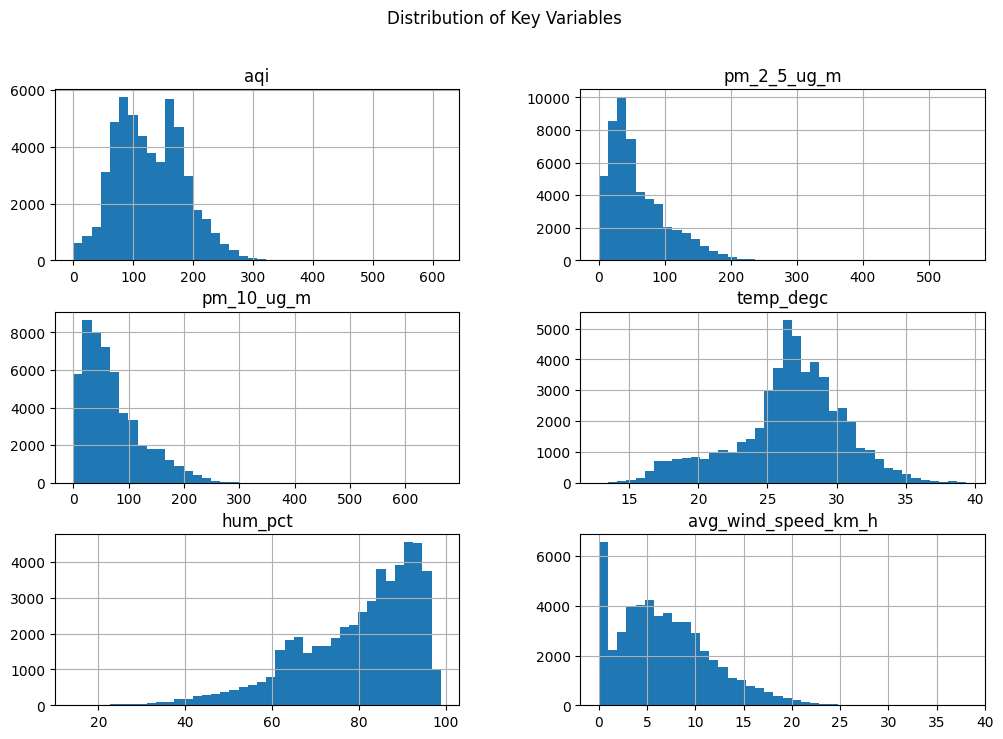

In [111]:
key_vars = [
    "aqi",
    "pm_2_5_ug_m",
    "pm_10_ug_m",
    "temp_degc",
    "hum_pct",
    "avg_wind_speed_km_h"
]

df[key_vars].hist(figsize=(12,8), bins=40)

plt.suptitle("Distribution of Key Variables")
plt.show()

### Distribution of Key Environmental Variables

The distribution plots of the primary environmental variables provide insight into the statistical characteristics and variability of the dataset after preprocessing. These histograms help identify the typical value ranges, skewness, and potential outliers in the variables that are most relevant for **AQI and temperature prediction**.

The histogram of **Air Quality Index (AQI)** shows that the majority of observations fall roughly between **70 and 180**, with the highest concentration around the **100–150 range**. This indicates that air quality conditions in the dataset are most frequently in the **moderate to unhealthy-for-sensitive-groups categories**. The distribution is moderately right-skewed, with fewer occurrences of very high AQI values beyond 200. Such a pattern suggests that extreme pollution events are relatively rare but still present, which is typical for urban atmospheric datasets where pollution spikes occur during certain meteorological conditions such as stagnant air or increased emissions.

The distribution of **PM2.5 concentrations** exhibits a strong **right-skewed pattern**, where a large number of observations are clustered at lower concentration levels while progressively fewer observations occur at higher values. This is characteristic of particulate pollution data, where most time periods experience relatively low to moderate particulate levels, while occasional pollution episodes cause large spikes. The long tail extending toward higher values indicates the presence of intermittent high pollution events, which significantly influence AQI values since PM2.5 is one of the dominant contributors to AQI calculations.

A similar pattern can be observed in the **PM10 distribution**, which also shows a right-skewed shape with most values concentrated below approximately **120 µg/m³**. Like PM2.5, PM10 concentrations tend to remain relatively low during normal atmospheric conditions but can increase during events such as dust transport, construction activity, or reduced atmospheric dispersion. The similarity between the PM2.5 and PM10 distributions further supports the expectation that particulate pollutants are strongly correlated and play a major role in determining overall air quality.

The histogram of **temperature (temp_degc)** reveals a roughly **bell-shaped distribution** centered around **26–29°C**, which suggests that the dataset predominantly captures warm climatic conditions. This is consistent with the geographical and seasonal context of the data, where temperatures tend to remain within a moderate to warm range for most of the year. The relatively symmetric distribution indicates that temperature varies gradually over time without extreme fluctuations, making it a stable environmental variable for predictive modeling.

In contrast, the distribution of **relative humidity (hum_pct)** shows a noticeable skew toward higher humidity levels, with most observations concentrated between **70% and 95%**. This indicates that the dataset represents a predominantly humid environment, which is typical for coastal or monsoon-influenced climates. High humidity levels are particularly relevant in air quality analysis because they influence particulate formation, aerosol chemistry, and pollutant dispersion dynamics.

Finally, the distribution of **average wind speed (avg_wind_speed_km_h)** shows that most wind speeds fall within a relatively low range, typically between **2 and 10 km/h**, with fewer occurrences of stronger winds. The right-skewed distribution indicates that calm or low-wind conditions are common, while strong wind events are comparatively rare. Wind speed is a critical meteorological factor affecting air quality, as stronger winds promote pollutant dispersion, while low wind speeds can lead to pollutant accumulation near the surface.

Overall, these distribution plots highlight the statistical properties of the environmental variables used in the dataset. The presence of right-skewed pollutant distributions, relatively stable temperature patterns, high humidity conditions, and generally low wind speeds suggests a typical urban atmospheric environment where pollution levels are influenced by both emission sources and meteorological conditions. Understanding these distributions is important for selecting appropriate modeling approaches and transformations during the time-series prediction stage.


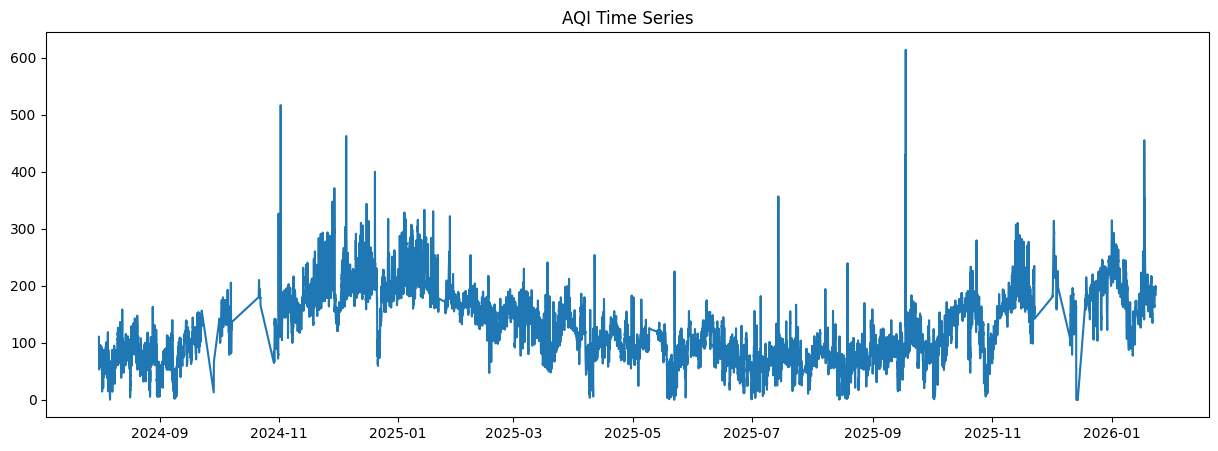

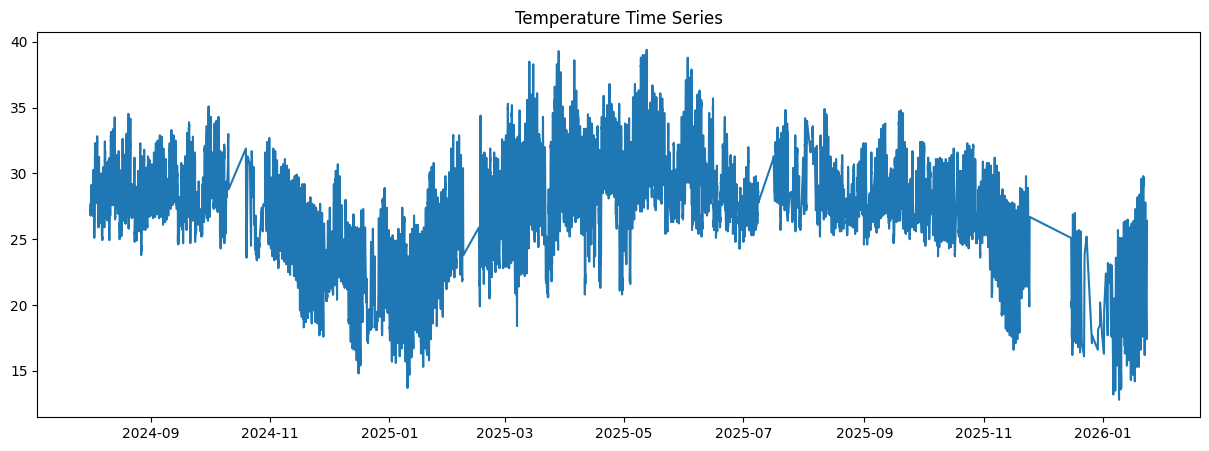

In [112]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["aqi"])
plt.title("AQI Time Series")
plt.show()


plt.figure(figsize=(15,5))
plt.plot(df.index, df["temp_degc"])
plt.title("Temperature Time Series")
plt.show()

### Temporal Behavior of AQI and Temperature

The time-series plots of **AQI** and **temperature** provide insight into the temporal dynamics of air quality and meteorological conditions across the observation period. These plots allow us to examine long-term trends, seasonal variations, and short-term fluctuations that are important for building predictive time-series models.

The **AQI time series** demonstrates significant variability over time, with both gradual trends and abrupt spikes. For most of the observed period, AQI values fluctuate between approximately **50 and 200**, indicating moderate to occasionally unhealthy air quality conditions. However, several sharp peaks exceeding **300 and even reaching above 600** are visible, representing episodic pollution events. These spikes likely correspond to periods of unfavorable atmospheric conditions such as low wind speeds, increased emissions, or thermal inversions that trap pollutants near the surface. Additionally, the AQI series exhibits noticeable seasonal variation. Higher pollution levels appear during certain months, particularly toward the late autumn and winter periods, while comparatively lower AQI values are observed during mid-year months. Such seasonal patterns are commonly associated with changes in atmospheric stability, rainfall patterns, and regional emission activities. The presence of both short-term fluctuations and seasonal trends suggests that AQI is influenced by a combination of meteorological conditions and environmental factors, making it well-suited for time-series modeling approaches that capture temporal dependencies.

The **temperature time series**, on the other hand, displays a much smoother and more structured pattern compared to AQI. Temperature values generally range between approximately **15°C and 40°C**, with most observations clustered between **25°C and 32°C**. Unlike AQI, temperature exhibits a clear **seasonal cycle** rather than abrupt spikes. The plot shows gradual warming and cooling phases that correspond to seasonal transitions throughout the year. For example, lower temperatures appear during winter months, while higher temperatures occur during late spring and early summer. These gradual transitions indicate strong temporal continuity, meaning that temperature values at a given time are highly dependent on recent observations. This smooth and predictable pattern is typical of meteorological variables and makes temperature particularly amenable to forecasting models that exploit temporal autocorrelation.

Comparing the two series highlights an important distinction in their temporal behavior. While temperature evolves gradually and follows relatively predictable seasonal cycles, AQI exhibits more irregular and volatile dynamics driven by both environmental conditions and episodic pollution events. Nevertheless, certain patterns in AQI appear to coincide with broader seasonal trends, suggesting that meteorological variables such as temperature, humidity, and wind speed may influence air quality levels. Understanding these temporal characteristics is essential for designing effective forecasting models, as it indicates that AQI prediction may require models capable of capturing both **short-term fluctuations and longer seasonal patterns**, whereas temperature prediction primarily relies on modeling smoother and more continuous temporal trends.


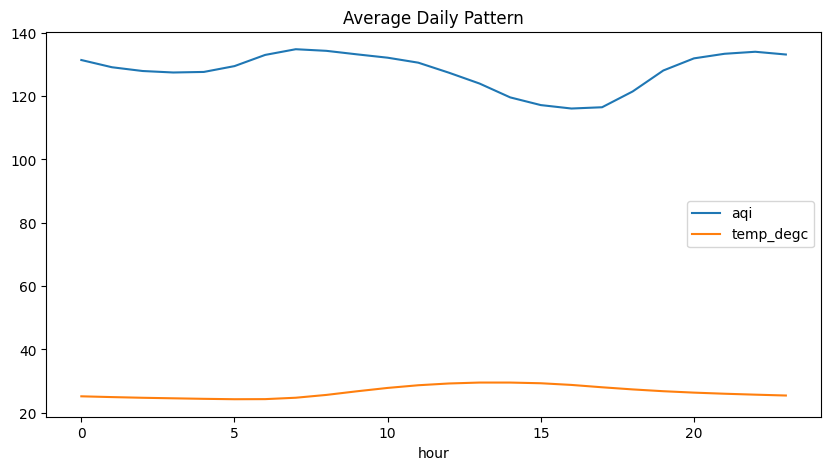

In [113]:
df["hour"] = df.index.hour

hourly_pattern = df.groupby("hour")[["aqi","temp_degc"]].mean()

hourly_pattern.plot(figsize=(10,5))

plt.title("Average Daily Pattern")
plt.show()

### Average Daily Pattern of AQI and Temperature

The plot illustrating the **average daily pattern** represents the mean values of AQI and temperature aggregated by hour of the day across the entire dataset. By grouping the data by the hour component of the timestamp and averaging the observations, this visualization highlights the **typical diurnal cycle** of both variables. Such patterns are important in environmental time-series analysis because many atmospheric processes exhibit strong daily periodicity driven by solar radiation, human activity cycles, and atmospheric mixing processes.

The **AQI curve** shows noticeable variation throughout the day, with relatively higher values during the early morning hours and again during the late evening and nighttime periods. AQI levels appear to decrease gradually during the daytime, reaching their lowest levels in the mid-afternoon. This pattern is consistent with well-known atmospheric dynamics. During the daytime, increased solar heating causes stronger vertical air mixing in the atmosphere, which helps disperse pollutants and reduces their concentration near the surface. In contrast, during nighttime and early morning hours, the atmosphere tends to become more stable with weaker air circulation, allowing pollutants to accumulate closer to ground level. Additionally, human activity patterns such as morning and evening traffic can contribute to higher pollutant concentrations during these periods.

The **temperature curve**, in contrast, exhibits a typical diurnal temperature cycle. Temperatures are lowest during the early morning hours, gradually increasing throughout the morning as solar radiation intensifies. The highest average temperatures occur around early to mid-afternoon, after which temperatures begin to decline slowly as solar heating decreases toward evening and nighttime. This smooth rise and fall in temperature reflects the natural daily heating and cooling cycle driven by the sun’s radiation and the thermal response of the Earth's surface.

When comparing the two curves, an inverse relationship between AQI and temperature can be observed during certain periods of the day. As temperature increases toward midday and early afternoon, AQI tends to decline, suggesting that stronger atmospheric mixing during warmer conditions helps disperse pollutants. Conversely, during cooler nighttime conditions, pollutant concentrations increase due to reduced atmospheric turbulence and pollutant dispersion. This daily pattern highlights the strong influence of meteorological conditions on air quality dynamics and suggests that incorporating time-of-day features and temperature-related variables may improve the performance of predictive models for AQI forecasting.


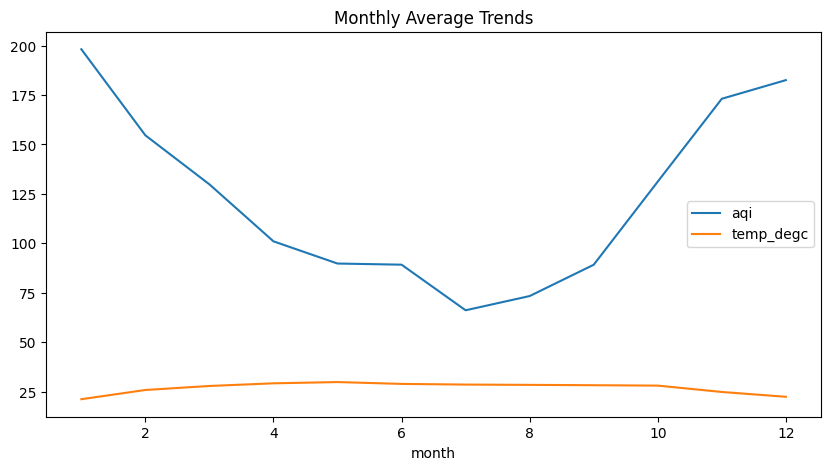

In [114]:
df["month"] = df.index.month

monthly_avg = df.groupby("month")[["aqi","temp_degc"]].mean()

monthly_avg.plot(figsize=(10,5))

plt.title("Monthly Average Trends")
plt.show()

### Monthly Average Trends of AQI and Temperature

The monthly average trends plot illustrates the seasonal variation in both **AQI** and **temperature** across the dataset. By aggregating observations by month and computing their mean values, this visualization highlights broader seasonal patterns that may not be easily visible in short-term time-series plots. Understanding these seasonal cycles is essential for air quality forecasting because atmospheric conditions, emission patterns, and meteorological processes vary significantly throughout the year.

The **AQI trend** shows a pronounced seasonal pattern. Higher AQI values are observed during the beginning and end of the year, with the highest averages occurring around **January and December**, where AQI values approach approximately **180–200**. Following this peak, AQI gradually decreases through the early months of the year, reaching its lowest levels around **June and July**, where average values fall to roughly **65–70**. After mid-year, AQI begins to increase again through the later months. This pattern is consistent with typical seasonal air quality dynamics. During winter months, atmospheric conditions often become more stable, reducing vertical mixing and allowing pollutants to accumulate near the surface. Additionally, increased human activities such as heating, industrial processes, and traffic may contribute to higher emission levels. In contrast, during mid-year months, stronger solar heating, increased wind circulation, and in many regions the presence of rainfall contribute to improved atmospheric dispersion and pollutant removal, resulting in lower AQI values.

The **temperature trend** follows a more gradual and smooth seasonal cycle. Temperatures increase steadily from the early months of the year, reaching a peak during the late spring and early summer months around **April and May**, where the average temperature approaches approximately **30°C**. After this peak, temperatures remain relatively stable for several months before gradually decreasing toward the end of the year. This seasonal progression reflects the natural annual heating cycle driven by solar radiation and climatic conditions.

Comparing the two curves reveals an inverse relationship between AQI and temperature across seasons. As temperatures rise during the middle of the year, AQI levels generally decrease, suggesting that warmer conditions may enhance atmospheric mixing and pollutant dispersion. Conversely, during cooler months when atmospheric stability increases, pollutant accumulation becomes more likely, leading to higher AQI values. These seasonal patterns emphasize the strong influence of meteorological factors on air quality and indicate that incorporating **seasonal features such as month or seasonal indicators** could improve the performance of predictive models. Additionally, the clear periodic structure observed in both AQI and temperature suggests that time-series forecasting models should account for **seasonal components** to capture these recurring annual trends effectively.


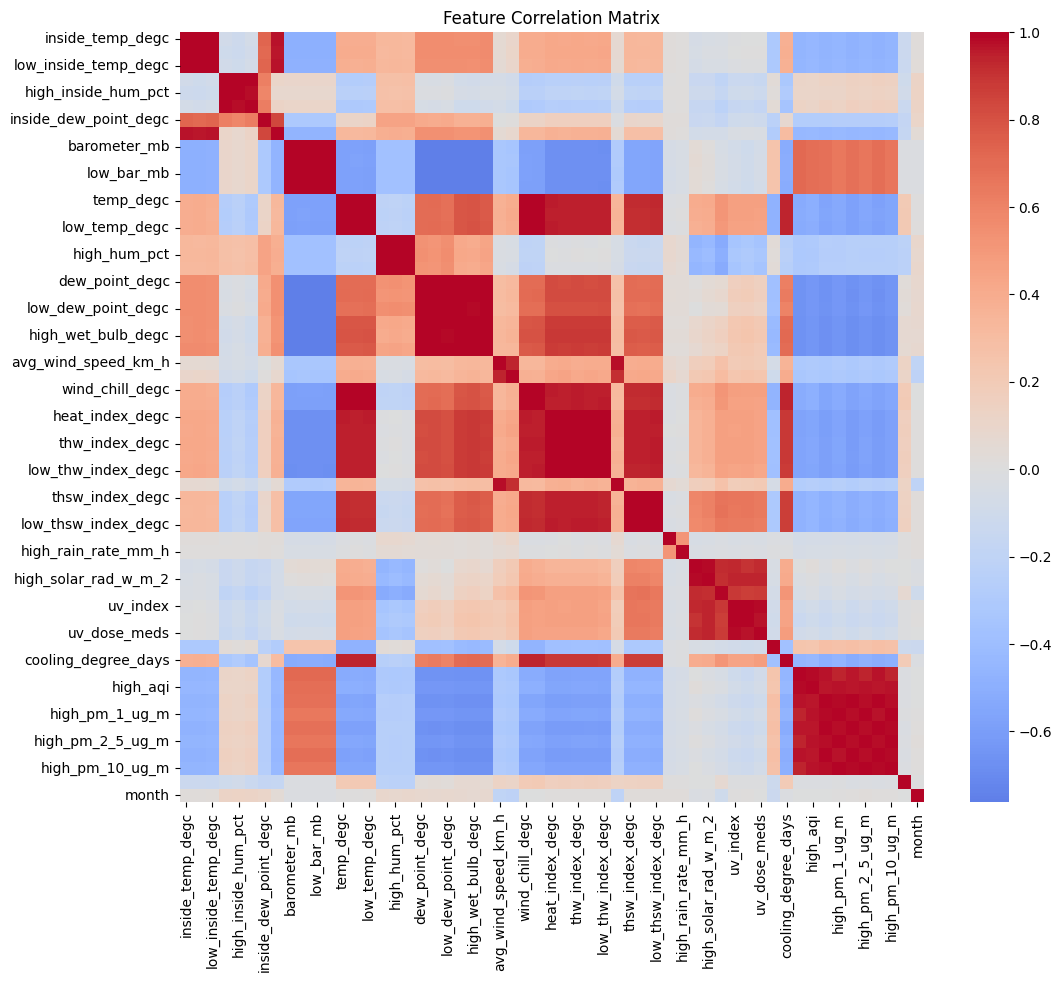

In [115]:
corr = df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Feature Correlation Matrix")

plt.show()

### Feature Correlation Analysis

The feature correlation matrix provides a comprehensive overview of the linear relationships between the variables present in the dataset. Each cell in the heatmap represents the **Pearson correlation coefficient** between two variables, with values ranging from **−1 to 1**. Positive correlations indicate that two variables tend to increase together, while negative correlations indicate that as one variable increases, the other tends to decrease. Visualizing these relationships helps identify strongly related variables, potential redundancies, and the key predictors that may influence AQI and temperature.

One of the most noticeable patterns in the matrix is the strong positive correlation among **temperature-related variables**, including temperature, dew point, wet bulb temperature, heat index, THW index, and THSW index. These variables are derived from similar atmospheric conditions and therefore exhibit very high correlations with each other. For example, heat index and THW index are calculated using temperature and humidity inputs, which explains why they closely follow the temperature trends. This cluster of strongly correlated features indicates that these variables contain overlapping information about thermal conditions in the atmosphere. While they may provide useful contextual signals, some of them may also be redundant in predictive models and could potentially be reduced through feature selection techniques.

Another clear pattern emerges among the **solar radiation and ultraviolet-related variables**, such as solar radiation, UV index, and UV dose. These variables are strongly correlated because they all represent different aspects of solar energy reaching the Earth's surface. Higher solar radiation typically corresponds to higher UV index values and greater UV dose accumulation. These features are particularly relevant for understanding daytime atmospheric conditions, as solar radiation influences atmospheric heating, convection, and photochemical reactions that can affect pollutant formation.

The matrix also highlights strong correlations between **particulate matter measurements**, specifically PM1, PM2.5, and PM10. These pollutants originate from similar emission sources and atmospheric processes, which explains why their concentrations tend to rise and fall together. Because particulate matter levels directly influence AQI calculations, the strong correlation between these variables confirms their central role in determining overall air quality conditions. This relationship suggests that particulate measurements will likely be among the most important predictors for AQI forecasting models.

Meteorological variables such as **wind speed and barometric pressure** show weaker correlations with most other variables. This is expected because these factors influence pollutant dispersion rather than directly contributing to pollutant formation. For instance, higher wind speeds can dilute pollutant concentrations by increasing atmospheric mixing, but this effect may not always appear as a strong linear correlation in aggregated datasets.

The correlation matrix also reveals a moderate relationship between **seasonal indicators and environmental variables**, represented by the inclusion of the month variable. This suggests that certain environmental conditions follow seasonal cycles, reinforcing earlier observations from the monthly trend analysis. Seasonal variation plays an important role in shaping both temperature and air quality dynamics, as factors such as solar radiation, rainfall, and atmospheric circulation patterns change throughout the year.

Overall, the correlation analysis highlights several key insights about the dataset. Environmental variables tend to cluster into groups representing **thermal conditions, solar radiation effects, and particulate pollution**, each contributing differently to the atmospheric system. The strong relationships among derived meteorological indices suggest potential redundancy, while the strong correlations among particulate matter variables confirm their central role in determining AQI. These findings are valuable for guiding **feature selection and model design**, as they help identify the most informative variables while avoiding unnecessary duplication of highly correlated features.


In [116]:
aqi_corr = corr["aqi"].sort_values(ascending=False)

display(aqi_corr)

aqi                       1.000000
high_aqi                  0.984717
pm_1_ug_m                 0.967392
pm_10_ug_m                0.966413
pm_2_5_ug_m               0.963347
high_pm_1_ug_m            0.944003
high_pm_10_ug_m           0.942964
high_pm_2_5_ug_m          0.940907
low_bar_mb                0.716139
absolute_pressure_mb      0.716110
barometer_mb              0.716107
high_bar_mb               0.715631
heating_degree_days       0.249126
low_inside_hum_pct        0.126909
inside_hum_pct            0.117413
high_inside_hum_pct       0.107929
solar_rad_w_m_2           0.001316
month                    -0.002210
hour                     -0.017876
high_solar_rad_w_m_2     -0.030640
et_mm                    -0.051113
high_rain_rate_mm_h      -0.053370
rain_mm                  -0.073353
uv_dose_meds             -0.093419
uv_index                 -0.106858
high_uv_index            -0.129166
wind_run_km              -0.277487
inside_dew_point_degc    -0.278512
low_hum_pct         

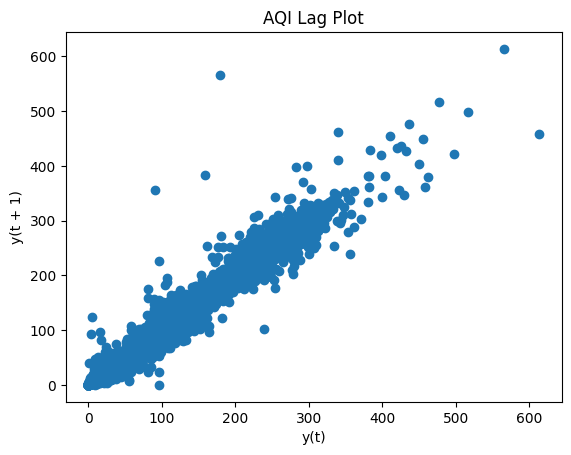

In [117]:
from pandas.plotting import lag_plot

lag_plot(df["aqi"])

plt.title("AQI Lag Plot")

plt.show()

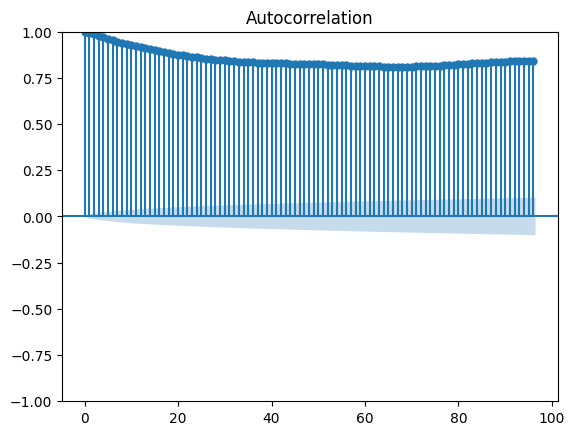

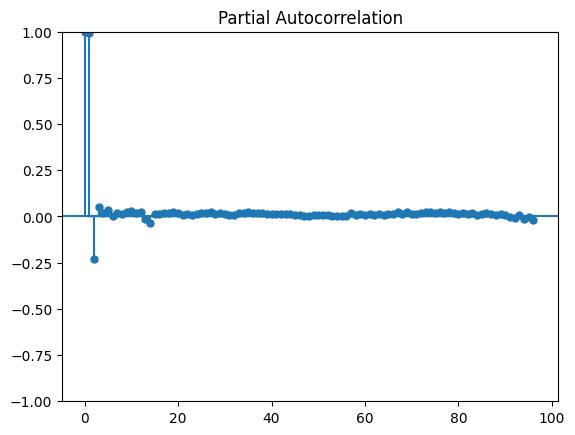

In [118]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df["aqi"], lags=96)
plt.show()

plot_pacf(df["aqi"], lags=96)
plt.show()

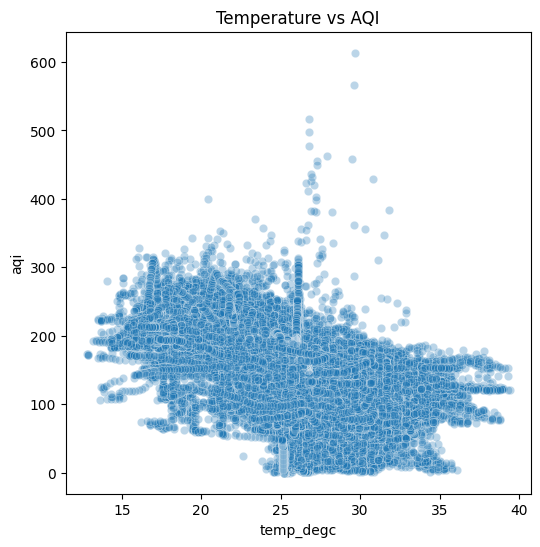

In [119]:
plt.figure(figsize=(6,6))

sns.scatterplot(x=df["temp_degc"], y=df["aqi"], alpha=0.3)

plt.title("Temperature vs AQI")

plt.show()

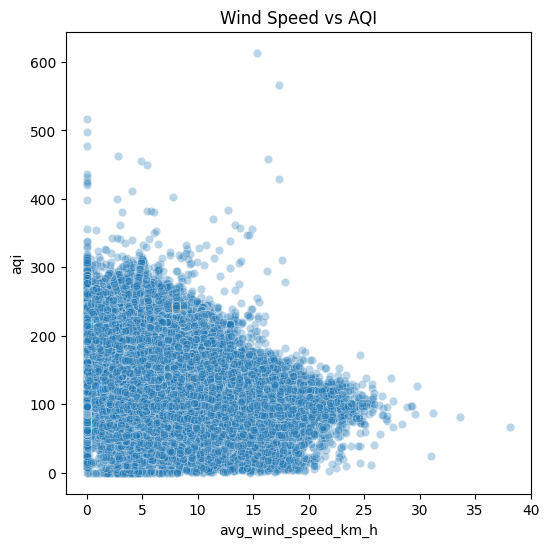

In [120]:
plt.figure(figsize=(6,6))

sns.scatterplot(x=df["avg_wind_speed_km_h"], y=df["aqi"], alpha=0.3)

plt.title("Wind Speed vs AQI")

plt.show()

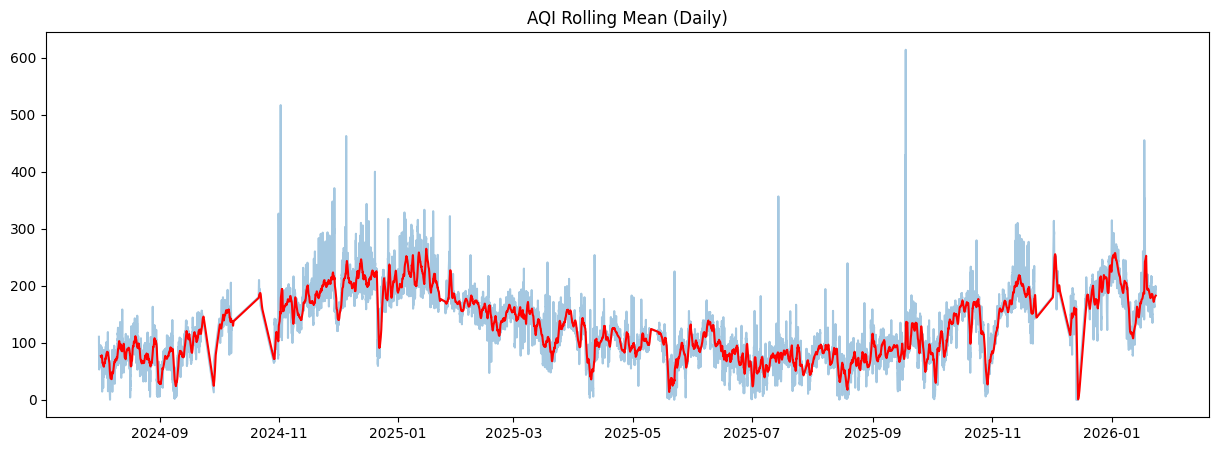

In [121]:
df["aqi_rolling"] = df["aqi"].rolling(96).mean()

plt.figure(figsize=(15,5))

plt.plot(df["aqi"], alpha=0.4)
plt.plot(df["aqi_rolling"], color="red")

plt.title("AQI Rolling Mean (Daily)")
plt.show()

### AQI Rolling Mean Trend Analysis

The rolling mean plot of AQI provides a smoothed representation of air quality trends over time by averaging AQI values within a moving window of observations. In this visualization, the raw AQI values are displayed as a light blue series, while the red line represents the **daily rolling mean**, which helps reduce short-term fluctuations and highlight broader temporal trends. This smoothing technique is particularly useful in time-series analysis because environmental measurements such as air pollution often contain substantial short-term variability caused by localized events, measurement noise, or sudden emission spikes.

From the plot, it is evident that the raw AQI values fluctuate significantly throughout the dataset, with numerous short-term spikes that represent sudden increases in pollution levels. These spikes can arise from episodic factors such as traffic congestion, industrial emissions, atmospheric stagnation, or weather events. While these abrupt changes are important for real-time monitoring, they can obscure longer-term patterns when analyzing the data directly. The rolling mean helps address this issue by averaging nearby values and revealing the underlying trend in air quality conditions.

The smoothed AQI curve demonstrates clear periods of gradual increases and decreases over time. Higher AQI levels are visible during certain periods, particularly toward the late months of the year and early months of the following year, while lower AQI levels appear during the middle portion of the timeline. This pattern is consistent with seasonal variations observed in earlier analyses, where atmospheric conditions such as rainfall, wind circulation, and temperature influence pollutant dispersion. During seasons with stronger atmospheric mixing and precipitation, pollutants tend to disperse more effectively, resulting in lower AQI values. Conversely, during periods with more stable atmospheric conditions, pollutant accumulation can lead to elevated AQI levels.

Another important observation is that although the raw AQI values contain sharp peaks, the rolling mean curve changes more gradually. This indicates that many extreme spikes are **short-lived events** rather than persistent pollution episodes. The rolling average therefore provides a more stable indicator of the general air quality conditions over time.

From a modeling perspective, the rolling mean analysis reveals that AQI exhibits **both short-term volatility and longer-term trends**, suggesting that predictive models should account for temporal dependencies at multiple time scales. Short-term lag features may capture sudden pollution spikes, while longer rolling averages can help represent underlying seasonal or trend components. Understanding this structure is essential when designing time-series forecasting models for air quality prediction.


## Forecasting

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [123]:
df = pd.read_csv("./cleaned/kiit_weather_cleaned.csv")

df["date_time"] = pd.to_datetime(df["date_time"])

df = df.sort_values("date_time")

df.set_index("date_time", inplace=True)

# Target variable
series = df["aqi"]

In [124]:
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

In [125]:
arima_model = ARIMA(train, order=(5,1,2))

arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

/home/apathak/Code/weather/VENV/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/home/apathak/Code/weather/VENV/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/home/apathak/Code/weather/VENV/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/home/apathak/Code/weather/VENV/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
sarima_model = SARIMAX(
    train,
    order=(2,1,2),
    seasonal_order=(1,1,1,96)
)

sarima_fit = sarima_model.fit()

sarima_forecast = sarima_fit.forecast(steps=len(test))

/home/apathak/Code/weather/VENV/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)
/home/apathak/Code/weather/VENV/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 15min will be used.
  self._init_dates(dates, freq)


In [ ]:
def evaluate(true, pred):

    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / true)) * 100

    return mae, rmse, mape

In [ ]:
arima_mae, arima_rmse, arima_mape = evaluate(test, arima_forecast)

print("ARIMA Performance")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test, label="Actual")

plt.plot(test.index, arima_forecast, label="ARIMA")

plt.plot(test.index, sarima_forecast, label="SARIMA")

plt.legend()

plt.title("AQI Forecast Comparison")

plt.show()